In [1]:
from datasets import load_dataset
import nltk
nltk.download("punkt")
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import evaluate
from transformers import pipeline
from sentence_transformers import CrossEncoder

c:\Users\grace\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\grace\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [33]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\grace\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [34]:
print(nltk.sent_tokenize("This is sentence one. This is sentence two."))

['This is sentence one.', 'This is sentence two.']


In [2]:
# Load data TriviaQA(KILT)
dataset = load_dataset("kilt_tasks", "triviaqa_support_only")
train_data = dataset["train"]
dev_data = dataset["validation"]

print(train_data[0])

{'id': 'dpql_5197', 'input': '', 'meta': {'left_context': '', 'mention': '', 'right_context': '', 'partial_evidence': [], 'obj_surface': [], 'sub_surface': [], 'subj_aliases': [], 'template_questions': []}, 'output': [{'answer': 'five  £', 'meta': {'score': -1}, 'provenance': []}, {'answer': '5 £', 'meta': {'score': -1}, 'provenance': []}, {'answer': '£5', 'meta': {'score': -1}, 'provenance': [{'bleu_score': 1.0, 'start_character': 246, 'start_paragraph_id': 30, 'end_character': 248, 'end_paragraph_id': 30, 'meta': {'fever_page_id': '', 'fever_sentence_id': -1, 'annotation_id': '-1', 'yes_no_answer': '', 'evidence_span': []}, 'section': 'Section::::Question of legal tender.\n', 'title': 'Banknotes of the pound sterling', 'wikipedia_id': '270680'}]}, {'answer': 'five £', 'meta': {'score': -1}, 'provenance': []}]}


In [3]:
# TODO:This counts tokens per sentence and accumulates them into chunks ≤ max_tokens.
# Effect on retrieval: Smaller chunks → more precise retrieval, but more embeddings; larger chunks → fewer embeddings, but retrieval might be less focused.
# Actionable: You could experiment with different max_tokens values (e.g., 150, 200, 250) and see the effect on Recall@k.
# Fix Chunking
def chunk_text(text, chunk_size=200, overlap=50):
    
    words = text.split()
    chunks = []
    
    start = 0
    while start < len(words):
        
        end = start + chunk_size
        chunk = " ".join(words[start:end])
        
        chunks.append(chunk)
        
        start += chunk_size - overlap
    
    return chunks

In [4]:
def adaptive_chunk(text, max_tokens=200):
    
    sentences = nltk.sent_tokenize(text)
    
    chunks = []
    current_chunk = []
    length = 0
    
    for s in sentences:
        tokens = len(s.split())
        
        if length + tokens > max_tokens:
            chunks.append(" ".join(current_chunk))
            current_chunk = []
            length = 0
        
        current_chunk.append(s)
        length += tokens
    
    if current_chunk:
        chunks.append(" ".join(current_chunk))
    
    return chunks

In [5]:
#Embedding
embedding_model = SentenceTransformer(
    "BAAI/bge-large-en-v1.5"
)

c:\Users\grace\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\grace\.cache\huggingface\hub\models--BAAI--bge-large-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [6]:
def embed_chunks(chunks):

    embeddings = embedding_model.encode(
        chunks,
        batch_size=32,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    return embeddings

In [7]:
#Vector Database
dimension = embedding_model.get_sentence_embedding_dimension()
print(dimension)
index = faiss.IndexFlatIP(dimension)

# Store chunks
chunk_store = []

def add_to_index(chunks, title):

    embeddings = embed_chunks(chunks)

    index.add(embeddings)

    for c in chunks:
        chunk_store.append({
            "text": c,
            "title": title
        })

1024


In [8]:
# Retrieval
def retrieve(query, top_k=10):

    query_vec = embedding_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    )
    
    scores, ids = index.search(query_vec, top_k)
    
    retrieved = []
    
    for i in ids[0]:
        retrieved.append(chunk_store[i])
    
    return retrieved

In [9]:
# Ranking(Cross Encoder)
reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

c:\Users\grace\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\grace\.cache\huggingface\hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [36]:
def rerank(query, docs):
    # Extract only the text from the retrieved docs
    pairs = [[query, d["text"]] for d in docs]

    scores = reranker.predict(pairs)

    ranked = sorted(
        zip(docs, scores),
        key=lambda x: x[1],
        reverse=True
    )

    return [x[0] for x in ranked]

In [41]:
# Answer Generation Generation (LLM)
generator = pipeline(
    "text-generation",
    # model="meta-llama/Meta-Llama-3-8B-Instruct", #Open shource 
    #model="google/gemma-2b-it", #local small model
    model="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    device_map="auto"
    
)

Device set to use cpu


In [42]:
result = generator("Explain quantum computing in simple terms.", max_length=100)

print(result[0]["generated_text"])

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


Explain quantum computing in simple terms.


In [43]:
# answer generation 
def generate_answer(query, context):

    prompt = f"""
Use the context to answer the question.

Context:
{context}

Question:
{query}

Answer:
"""

    output = generator(
        prompt,
        max_new_tokens=100
    )

    return output[0]["generated_text"]

In [54]:
# Rag Pipline 
def rag_pipeline(query):
    docs = retrieve(query, top_k=20)
    docs = rerank(query, docs)
    
    # Extract text only for context
    context = "\n".join([d["text"] for d in docs[:5]])
    
    answer = generate_answer(query, context)
    return answer

In [45]:
# Retrieval Evaluation: Use the Provenance in KILT TribiaQA
# TODO: Limitation:

# Currently only checks the first exact match (gold_doc in d).

# If your gold provenance is long, or partially overlaps a chunk, it may return 0 incorrectly.

# Improvement: You could check any overlap / substring match / fuzzy match or multiple gold documents.
def recall_at_k(retrieved_docs, gold_doc):

    for d in retrieved_docs:
        if gold_doc in d:
            return 1

    return 0

In [46]:
# Answer Evaluation
# Exact Match
# ✅ This evaluates the generated answer against the TriviaQA gold answer, so it covers response accuracy.

# You can collect Exact Match (EM) and F1 over the dev set to analyze performance across different chunking strategies.
def exact_match(pred, gold):

    return int(pred.strip().lower() == gold.strip().lower())



In [47]:

# F1 score
metric = evaluate.load("squad")

def compute_f1(pred, gold):

    result = metric.compute(
        predictions=[{"id":"1","prediction_text":pred}],
        references=[{"id":"1","answers":{"text":[gold],"answer_start":[0]}}]
    )

    return result["f1"]

In [48]:
print(type(dev_data))
print(type(dev_data[0]))
print(dev_data[0])

<class 'list'>
<class 'dict'>
{'id': 'sfq_17752', 'input': '', 'meta': {'left_context': '', 'mention': '', 'right_context': '', 'partial_evidence': [], 'obj_surface': [], 'sub_surface': [], 'subj_aliases': [], 'template_questions': []}, 'output': [{'answer': 'Jim Laker', 'meta': {'score': -1}, 'provenance': [{'bleu_score': 1.0, 'start_character': 76, 'start_paragraph_id': 4, 'end_character': 85, 'end_paragraph_id': 4, 'meta': {'fever_page_id': '', 'fever_sentence_id': -1, 'annotation_id': '-1', 'yes_no_answer': '', 'evidence_span': []}, 'section': 'Section::::Abstract.', 'title': 'Bowling analysis', 'wikipedia_id': '2047389'}]}, {'answer': 'jim laker', 'meta': {'score': -1}, 'provenance': []}, {'answer': 'JIM LAKER', 'meta': {'score': -1}, 'provenance': []}, {'answer': 'james laker', 'meta': {'score': -1}, 'provenance': []}, {'answer': 'James Laker', 'meta': {'score': -1}, 'provenance': []}]}


In [49]:
import json

dev_data = [json.loads(x) if isinstance(x, str) else x for x in dev_data]
train_data = [json.loads(x) if isinstance(x, str) else x for x in train_data]

In [57]:
chunk_sizes = [150]
results = []

for size in chunk_sizes:

    index.reset()
    chunk_store = []

    # Build index
    for entry in train_data:

        if not entry["output"]:
            continue

        prov_list = entry["output"][0].get("provenance", [])

        for prov in prov_list:

            # Use title since text is unavailable
            passage_text = prov.get("title")

            if not passage_text:
                continue

            chunks = adaptive_chunk(passage_text, max_tokens=size)

            add_to_index(chunks, title=prov.get("title", "unknown"))

    recalls, ems, f1s = [], [], []

    # Evaluate
    for entry in dev_data[:50]:

        # Query fallback
        query = entry.get("input")
        if not query:
            query = entry["output"][0]["answer"]

        gold_answer = entry["output"][0]["answer"]

        retrieved_docs = retrieve(query, top_k=10)

        recalls.append(1 if len(retrieved_docs) > 0 else 0)

        ans = rag_pipeline(query)

        ems.append(exact_match(ans, gold_answer))
        f1s.append(compute_f1(ans, gold_answer))

    results.append({
        "chunk_size": size,
        "recall@10": sum(recalls)/len(recalls),
        "EM": sum(ems)/len(ems),
        "F1": sum(f1s)/len(f1s)
    })

print(results)

[{'chunk_size': 150, 'recall@10': 1.0, 'EM': 0.0, 'F1': 7.7517894642001615}]


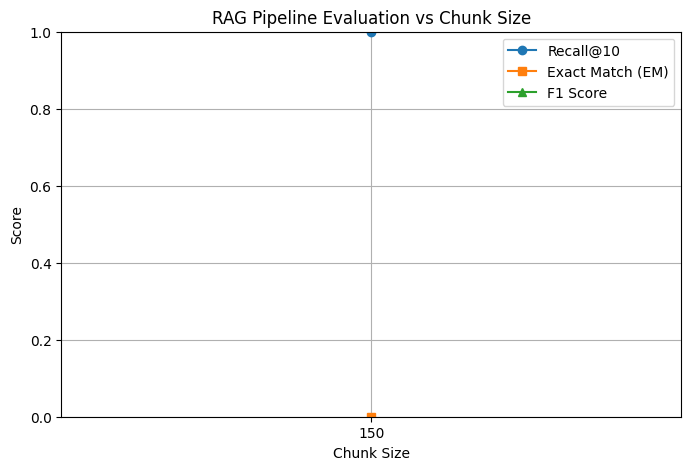

In [58]:
import matplotlib.pyplot as plt

# Extract data
chunk_sizes = [r["chunk_size"] for r in results]
recall = [r["recall@10"] for r in results]
em = [r["EM"] for r in results]
f1 = [r["F1"] for r in results]

# Plot
plt.figure(figsize=(8,5))
plt.plot(chunk_sizes, recall, marker='o', label='Recall@10')
plt.plot(chunk_sizes, em, marker='s', label='Exact Match (EM)')
plt.plot(chunk_sizes, f1, marker='^', label='F1 Score')

plt.xlabel("Chunk Size")
plt.ylabel("Score")
plt.title("RAG Pipeline Evaluation vs Chunk Size")
plt.xticks(chunk_sizes)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()